
## Fase 4 — Análise de Áudio Multimodal para Saúde da Mulher



### Objetivo

Este notebook tem como objetivo validar o pipeline de análise de áudio
utilizado na Fase 4 do Tech Challenge.

A proposta consiste em utilizar serviços cognitivos da Microsoft Azure
para realizar transcrição automática de fala (Speech-to-Text) e análise
de sentimento baseada em NLP, permitindo identificação de possíveis
sinais emocionais relacionados à ansiedade, medo e desconforto psicológico.



### Fundamentação Teórica

O processamento de fala utilizando Inteligência Artificial tem sido amplamente
utilizado em cenários de monitoramento emocional, atendimento clínico e
análise comportamental.

Neste projeto, foram utilizados serviços cognitivos da Microsoft Azure
para construção de um pipeline multimodal integrado em nuvem, permitindo
conversão de fala em texto e análise automática de sentimento.



### Motivação da Abordagem

O documento do desafio solicita explicitamente a utilização de análise
especializada de áudio e integração cloud.

Conforme orientação da disciplina, foram utilizados serviços cognitivos
pré-treinados visando acelerar o desenvolvimento da solução multimodal,
permitindo maior foco na integração entre vídeo, áudio e interpretação
dos resultados.



### Importação das Bibliotecas


In [1]:

from pathlib import Path
import json
import time
import os

import matplotlib.pyplot as plt
import pandas as pd
import librosa
import librosa.display

from pydub import AudioSegment

import azure.cognitiveservices.speech as speechsdk

from azure.core.credentials import AzureKeyCredential
from azure.ai.textanalytics import TextAnalyticsClient


b:\Pos\hospital-ai-diagnosis\.venv\Lib\site-packages\pydub\utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)



### Configuração dos Serviços Cognitivos Azure


In [2]:

SPEECH_KEY = os.getenv("AZURE_SPEECH_KEY")
SPEECH_REGION = os.getenv("AZURE_SPEECH_REGION")

LANGUAGE_KEY = os.getenv("AZURE_LANG_KEY")
LANGUAGE_ENDPOINT = os.getenv("AZURE_LANG_ENDPOINT")

print(LANGUAGE_ENDPOINT)

https://fiaplanguageservice.cognitiveservices.azure.com/



### Definição do Arquivo de Áudio


In [3]:

AUDIO_PATH = Path("../../dados/Fase 4/audio/1.wav")

AUDIO_PROCESSED_PATH = Path("../../dados/Fase 4/audio/processed/processed_1.wav")



### Normalização do Áudio

Antes da etapa de Speech-to-Text, o áudio é normalizado para o formato
compatível com o Azure Speech Service, garantindo maior estabilidade
durante o processamento multimídia.


In [4]:

def normalize_audio(input_path: Path, output_path: Path):

    audio = AudioSegment.from_file(str(input_path))

    audio = audio.set_channels(1)
    audio = audio.set_frame_rate(16000)
    audio = audio.set_sample_width(2)

    audio.export(
        str(output_path),
        format="wav"
    )

    return output_path



### Visualização do Waveform


b:\Pos\hospital-ai-diagnosis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


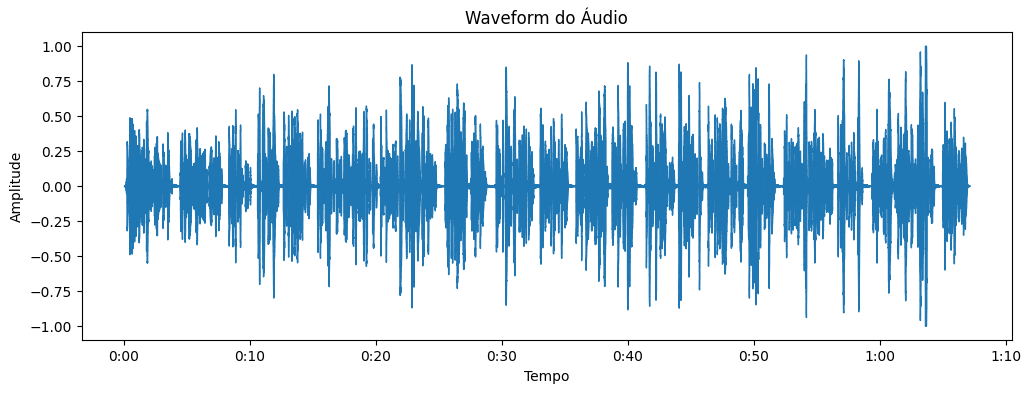

In [5]:

audio_signal, sample_rate = librosa.load(AUDIO_PATH, sr=None)

plt.figure(figsize=(12, 4))

librosa.display.waveshow(
    audio_signal,
    sr=sample_rate
)

plt.title("Waveform do Áudio")
plt.xlabel("Tempo")
plt.ylabel("Amplitude")

plt.show()



### Speech-to-Text com Azure Speech Service


In [6]:

def transcribe_audio(audio_path: Path) -> str:

    speech_config = speechsdk.SpeechConfig(
        subscription=SPEECH_KEY,
        region=SPEECH_REGION
    )

    speech_config.speech_recognition_language = "pt-BR"

    audio_config = speechsdk.audio.AudioConfig(
        filename=str(audio_path)
    )

    speech_recognizer = speechsdk.SpeechRecognizer(
        speech_config=speech_config,
        audio_config=audio_config
    )

    all_results = []

    speech_recognizer.recognized.connect(
        lambda evt: all_results.append(evt.result.text)
        if evt.result.text else None
    )

    speech_recognizer.start_continuous_recognition()

    time.sleep(10)

    speech_recognizer.stop_continuous_recognition()

    transcription = " ".join(all_results).strip()

    return transcription


normalize_audio(
    AUDIO_PATH,
    AUDIO_PROCESSED_PATH
)

transcription = transcribe_audio(
    AUDIO_PROCESSED_PATH
)

print("Transcrição:")
print(transcription)


Transcrição:
Doutora, eu não sei se é normal me sentir assim depois do parto. Já faz 3 meses e eu ainda me sinto muito cansada, mas não é só cansaço físico. Eu acordo já exausta, mesmo quando o bebê dorme a noite inteira. Eu tenho chorado por coisas pequenas e às vezes sinto um aperto no peito, como se eu tivesse sempre preocupada com alguma coisa ruim prestes a acontecer.



### Análise de Sentimento com Azure AI Language

Após a transcrição do áudio, o texto obtido é processado utilizando
Azure AI Language Service para análise automática de sentimento.

Essa abordagem permite identificar indicadores relacionados a emoções
negativas, neutralidade e possíveis sinais emocionais relevantes para
o pipeline multimodal.


In [7]:

language_client = TextAnalyticsClient(
    endpoint=LANGUAGE_ENDPOINT,
    credential=AzureKeyCredential(LANGUAGE_KEY)
)

response = language_client.analyze_sentiment(
    [transcription],
    language="pt"
)

result = response[0]

key_phrase_response = language_client.extract_key_phrases(
    [transcription],
    language="pt"
)

key_phrases = key_phrase_response[0].key_phrases

sentiment_data = {
    "sentiment": result.sentiment,
    "positive": result.confidence_scores.positive,
    "neutral": result.confidence_scores.neutral,
    "negative": result.confidence_scores.negative
}

sentiment_df = pd.DataFrame(
    sentiment_data.items(),
    columns=["metric", "score"]
)

print(key_phrases)
sentiment_df


['cansaço físico', 'Doutora', 'parto', '3 meses', 'bebê', 'coisas', 'pequenas', 'aperto', 'peito']


,metric,score
0,sentiment,negative
1,positive,0.0
2,neutral,0.0
3,negative,1.0



### Visualização dos Scores de Sentimento


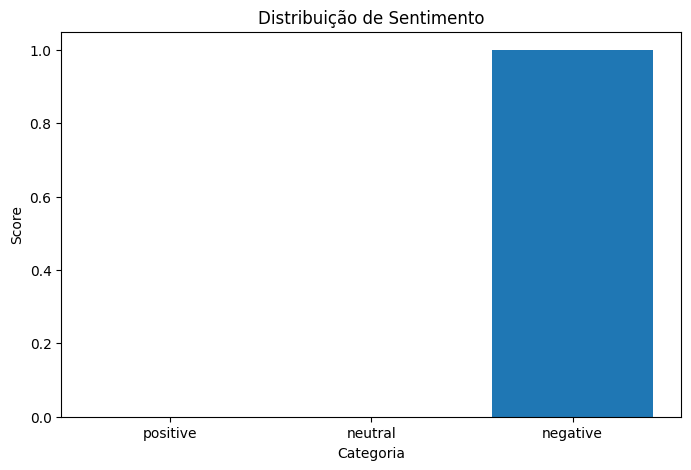

In [8]:

plot_df = sentiment_df[
    sentiment_df["metric"] != "sentiment"
]

plt.figure(figsize=(8, 5))

plt.bar(
    plot_df["metric"],
    plot_df["score"]
)

plt.title("Distribuição de Sentimento")
plt.xlabel("Categoria")
plt.ylabel("Score")

plt.show()



### Geração do Audio Risk Score


In [9]:

audio_risk_score = float(
    result.confidence_scores.negative
)

print(f"Audio Risk Score: {audio_risk_score:.2f}")


Audio Risk Score: 1.00



### Geração de Relatório Automático


In [10]:

audio_report = {
    "transcription": transcription,
    "sentiment": result.sentiment,
    "positive_score": result.confidence_scores.positive,
    "neutral_score": result.confidence_scores.neutral,
    "negative_score": result.confidence_scores.negative,
    "audio_risk_score": audio_risk_score,
    "interpretation": (
    f"Sentiment analysis identified predominantly "
    f"{result.sentiment} emotional indicators. "
    f"Relevant expressions extracted from the audio "
    f"include: {', '.join(key_phrases[:3])}."
)
}

print(json.dumps(audio_report, indent=4))


{
    "transcription": "Doutora, eu n\u00e3o sei se \u00e9 normal me sentir assim depois do parto. J\u00e1 faz 3 meses e eu ainda me sinto muito cansada, mas n\u00e3o \u00e9 s\u00f3 cansa\u00e7o f\u00edsico. Eu acordo j\u00e1 exausta, mesmo quando o beb\u00ea dorme a noite inteira. Eu tenho chorado por coisas pequenas e \u00e0s vezes sinto um aperto no peito, como se eu tivesse sempre preocupada com alguma coisa ruim prestes a acontecer.",
    "sentiment": "negative",
    "positive_score": 0.0,
    "neutral_score": 0.0,
    "negative_score": 1.0,
    "audio_risk_score": 1.0,
    "interpretation": "Sentiment analysis identified predominantly negative emotional indicators. Relevant expressions extracted from the audio include: cansa\u00e7o f\u00edsico, Doutora, parto."
}



### Interpretação dos Resultados

Os resultados demonstram a viabilidade da utilização de serviços cognitivos
em nuvem para construção de pipelines multimodais aplicados à análise
emocional de fala.

A integração entre Azure Speech Services e Azure AI Language permite
processamento completo de áudio, NLP e geração de indicadores emocionais
dentro de uma arquitetura cloud integrada.



### Conclusão

Este notebook demonstrou a viabilidade da análise de áudio utilizando
serviços cognitivos da Microsoft Azure como parte da solução multimodal
da Fase 4.

Os resultados obtidos servirão como base para integração futura com
os módulos de análise de vídeo, fusão multimodal e geração de alertas
especializados.
